In [11]:
import pickle

result_path = '../logs/combined_f_combined/border_cam_cue_conflict_shape.pkl'
with open(result_path, 'rb') as f:
    result = pickle.load(f)

In [14]:
result['ic']['test_f']

{'data/cue_conflict_f/output/d2c19f62d0ad4f6985457fc7a008e5cf_3_20240926081022_5_462498b44e9a413ea94c58724b69ded5.jpg': 0.66307366,
 'data/cue_conflict_f/output/3b9dfd93ea0a404fa7ba224a4f17d020_8_20240926083807_7_46fff6b2667f4a67b7a48d69dcb06adb.jpg': 0.502641,
 'data/cue_conflict_f/output/b843c63d853a4b788a6a6b1aad4b2c15_8_20240926084235_4_0b22a2f802214c28b88edb17606492a8.jpg': 0.6566006,
 'data/cue_conflict_f/output/9db7111830fe469bbcbe8d3fb356c7e4_1_20240926084145_5_4ec9181f5f274cacb2138714202020d1.jpg': 0.534787,
 'data/cue_conflict_f/output/4cbfd7400aa6477daa518b79712f1c43_0_20240925194721_8_3db1f4b37cf24982a353e52bb330f534.jpg': 0.7381385,
 'data/cue_conflict_f/output/4a8fe5925e1f4c7089befdf00de3a768_5_20240925224222_0_02af6a8de3a7493696361ee81650442c.jpg': 0.6088608,
 'data/cue_conflict_f/output/2cda50e73f69438598eabf8259e27cb7_3_20240926080424_15_4ffa78d0e5504da5a1f75ff73a439abf.jpg': 0.68670505,
 'data/cue_conflict_f/output/5d8d59f174e743c9a68a6b9b6084aa43_3_20240926080609_11_

In [23]:
result_path = '../logs/combined_f_combined/decision_filter.pkl'
with open(result_path, 'rb') as f:
    decision_filter = pickle.load(f)
decision_filter['isd']

{'f': ['data/cue_conflict_f/output/e5e0f42aec4846a0bff905d0601fdd1e_7_20240925225515_14_3781314af1954867a5eb2bca6c18a955.jpg',
  'data/cue_conflict_f/output/2de1dd3830864ade87756fbda17e6b22_3_20240925194302_1_0b22a2f802214c28b88edb17606492a8.jpg',
  'data/cue_conflict_f/output/18f79eefe54c4ec0a2a57987a071611a_1_20240926083647_1_4ec9181f5f274cacb2138714202020d1.jpg',
  'data/cue_conflict_f/output/1ff167f84cc64aa0a9aa55ae4691f0d7_0_20240926083706_12_3781314af1954867a5eb2bca6c18a955.jpg',
  'data/cue_conflict_f/output/c3a81a5f13274874b776761c6e64716e_3_20240925225214_10_b1dcc2e6d6f54aaa90c15d9092d0a32e.jpg',
  'data/cue_conflict_f/output/d515481fb818405fa39b16ad217031da_9_20240925225400_11_4ec9181f5f274cacb2138714202020d1.jpg',
  'data/cue_conflict_f/output/f51db55de0fb43ff834487c11ce38215_2_20240926084457_5_4ec9181f5f274cacb2138714202020d1.jpg',
  'data/cue_conflict_f/output/4fe0c97a751640d7a434f2e6b5461e46_0_20240925194734_15_b21ad606d20a467eac0e63e7d298488d.jpg',
  'data/cue_conflict_f

In [25]:
import os

backgrounds = ['combined']
views = ['f', 'r', 'er', 'fx']
ood_views = ['cr']
res = 'combined'
log_dir = '../logs'
cam_type = 'ic'
data_matched = []
for ind_background, background in enumerate(backgrounds):
    for ind_view, view in enumerate(views):
        for ind_ood, ood_view in enumerate(ood_views):
            log_folder = '_'.join([background, view, res])
            border_cam_path = os.path.join(log_dir, log_folder, 'border_cam.pkl')
            with open(border_cam_path, 'rb') as f:
                border_cam = pickle.load(f)
    
            values_matched = border_cam[cam_type][ood_view].values()
            data_matched.extend([(cam_type, views[ind_view], val) for i, val in enumerate(values_matched)])

In [26]:
import pandas as pd

df_matched = pd.DataFrame(data_matched, columns=['CAM Type', 'View', 'Value'])
pairs = [(views[i], views[j]) for i in range(len(views))
                 for j in range(i + 1, len(views))]
print(pairs)

[('f', 'r'), ('f', 'er'), ('f', 'fx'), ('r', 'er'), ('r', 'fx'), ('er', 'fx')]


In [19]:
df_matched['Value'].fillna(df_matched['Value'].mean(), inplace=True)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

f vs. r: t-test paired samples with Bonferroni correction, P_val:nan t=nan
r vs. er: t-test paired samples with Bonferroni correction, P_val:2.397e-03 t=3.542e+00
er vs. fx: t-test paired samples with Bonferroni correction, P_val:3.009e-257 t=3.558e+01
f vs. er: t-test paired samples with Bonferroni correction, P_val:2.397e-03 t=3.542e+00
r vs. fx: t-test paired samples with Bonferroni correction, P_val:0.000e+00 t=3.962e+01
f vs. fx: t-test paired samples with Bonferroni correction, P_val:0.000e+00 t=3.962e+01


(<Axes: title={'center': 'Ic CAM - Matched'}, xlabel='View', ylabel='Value'>,
  <statannotations.Annotation.Annotation at 0x1680897b0>])

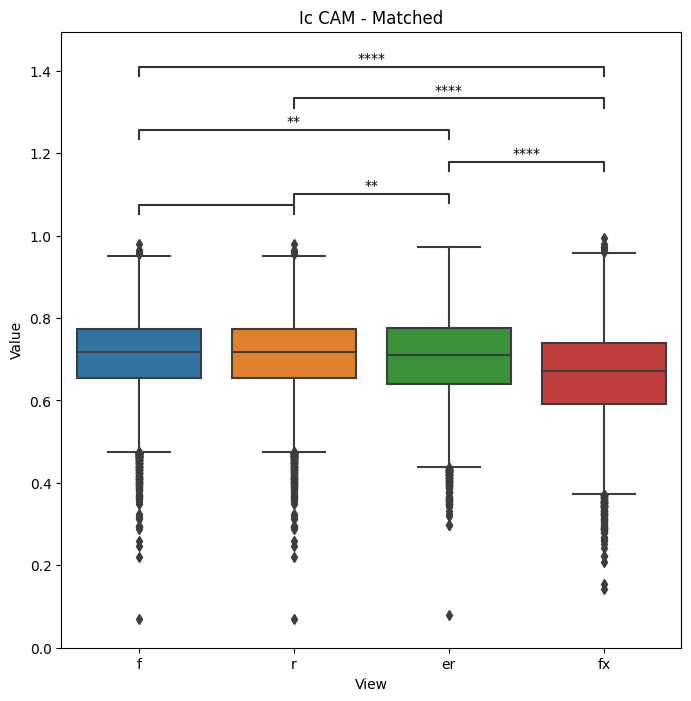

In [20]:
from statannotations.Annotator import Annotator
# Plot matched data
import seaborn as sns
from matplotlib import pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.boxplot(ax=ax, x='View', y='Value', data=df_matched)
ax.set_title(f'{cam_type.capitalize()} CAM - Matched')
ax.set_ylim(0, 1.1)
annotator = Annotator(ax, pairs, data=df_matched, x='View', y='Value')
annotator.configure(test='t-test_paired', text_format='star', comparisons_correction='bonferroni')
annotator.apply_and_annotate()

In [27]:
df_f = df_matched.loc[df_matched['View'] == 'f', ['Value']]
df_r = df_matched.loc[df_matched['View'] == 'r', ['Value']]

In [28]:
df_f

,Value
0,0.759196
1,0.595897
2,0.514040
3,0.682751
4,0.586151
...,...
8187,0.659159
8188,0.709423
8189,0.739439
8190,0.694806


In [29]:
df_r

,Value
8192,0.759196
8193,0.595897
8194,0.514040
8195,0.682751
8196,0.586151
...,...
16379,0.659159
16380,0.709423
16381,0.739439
16382,0.694806
